In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [ ]:
def d_score(df):
  
    df = df[df["score"] == 1].copy() 
    df = df[(df["rt"] >= 300) & (df["rt"] <= 10000)].copy() 

    congruent = df[df["block"] == 3]["rt"] 
    incongruent = df[df["block"] == 6]["rt"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 
    

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 
 
    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
   
    return d_score, len(df)

def d_with_penalty_ifn(df1):
    # dscore with penalty for (incorrect + failure + noise)
 
    df1 = df1[(df1["rt"] >= 300) & (df1["rt"] <= 10000)].copy() 
    df1["rt_adj"] = df1["rt"].astype(float)


    mean_c_correct = df1.loc[(df1["block"] == 3) & (df1["score"] == 1), "rt"].mean()
    mean_i_correct = df1.loc[(df1["block"] == 6) & (df1["score"] == 1), "rt"].mean()

    df1.loc[(df1["block"] == 3) & (df1["score"] == 0), "rt_adj"] = mean_c_correct + 600
    df1.loc[(df1["block"] == 6) & (df1["score"] == 0), "rt_adj"] = mean_i_correct + 600

    congruent = df1[df1["block"] == 3]["rt_adj"] 
    incongruent = df1[df1["block"] == 6]["rt_adj"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 

    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
    corr = len(df1[((df1["block"] == 3) & (df1["score"] == 1))|((df1["block"] == 6) & (df1["score"] == 1)) ])
    return d_score, corr 


def d_with_penalty_i(df1):
    # dscore with penalty for (incorrect only)
    df1 = df1[df1["response"].isin(['a','d'])].copy() 
    df1 = df1[(df1["rt"] >= 300) & (df1["rt"] <= 10000)].copy() 
    df1["rt_adj"] = df1["rt"].astype(float)


    mean_c_correct = df1.loc[(df1["block"] == 3) & (df1["score"] == 1), "rt"].mean()
    mean_i_correct = df1.loc[(df1["block"] == 6) & (df1["score"] == 1), "rt"].mean()
    

    df1.loc[(df1["block"] == 3) & (df1["score"] == 0), "rt_adj"] = mean_c_correct + 600
    df1.loc[(df1["block"] == 6) & (df1["score"] == 0), "rt_adj"] = mean_i_correct + 600

    congruent = df1[df1["block"] == 3]["rt_adj"] 
    incongruent = df1[df1["block"] == 6]["rt_adj"] 

    mean_c = congruent.mean() 
    mean_i = incongruent.mean() 

    sd_c = congruent.std(ddof=1) 
    sd_i = incongruent.std(ddof=1) 

    sd_pooled = np.sqrt((sd_c**2 + sd_i**2) / 2) 

    d_score = (mean_i - mean_c) / sd_pooled if sd_pooled != 0 else 0
    return d_score
 
def s_count_if_there(df1):
    return (df1["response"].astype(str).str.lower() == 's').sum()

def w_count_if_there(df1):
    return (df1["response"].astype(str).str.lower() == 'w').sum()

def incorrect_retrievals(df1):
    return ((df1["score"] == 0) & (df1["response"].isin(['d','a']))).sum()



In [ ]:
input_directory = "Outputs" 
all_scores = [] 
from pathlib import Path 
invalid_records=[]


for csv_path in Path(input_directory).rglob("*.csv"):
    try: 

        df = pd.read_csv(csv_path)
        if (not (df["rt"] <0 ).any()):
            d_score_without_penalty, correct_recs = d_score(df) 
            d_score_with_penalty,correct_test_recs = d_with_penalty_ifn(df) 
            d_score_with_penalty_only_c_ic = d_with_penalty_i(df)
            accuracy = (correct_recs/70) *100
            test_accuracy = (correct_test_recs/40) * 100
            s_count = s_count_if_there(df)
            w_count = w_count_if_there(df)
            inc = incorrect_retrievals(df)
            s_count_perc = (s_count/70)*100
            w_count_perc = (w_count/70)*100
            inc_perc = (inc/70)*100
            # if int(accuracy)>30 and int(test_accuracy)>30:
            # print(csv_path.name)
            all_scores.append({ 
                "relative_path": csv_path.parent.relative_to(input_directory).as_posix(),
                "file_name":  csv_path.name, 
                "d_score": d_score_without_penalty,
                "d_score_with_penalty":d_score_with_penalty,
                "d_score_with_penalty_only_c_ic":d_score_with_penalty_only_c_ic,
                "s_count":s_count,
                "w_count":w_count,
                "correct_recs": correct_recs,
                "accuracy":accuracy,
                "correct_test_recs":correct_test_recs,
                "test_accuracy":test_accuracy,
                "incorrect_recs": inc,
                "noise_perc":s_count_perc,
                "failure_perc":w_count_perc,
                "inc_perc":inc_perc

            }) 
        else:
            invalid_records.append(csv_path.name)

    except Exception as e: 
        print(f"Error processing { csv_path.name}: {e}") 

df1 = pd.DataFrame(all_scores) 

 

In [ ]:
columns = df1.columns[2:]
grouped = df1.groupby("relative_path")[columns].agg(["mean","sem"])
grouped.columns = [f"{column}_{stat}" for column,stat in grouped.columns] 
grouped["count"] = df1.groupby("relative_path").size()
grouped = grouped.reset_index()

In [ ]:

order= ['Baseline', 'Chunk All', 'Chunk Black','Chunk White','Corpus All', 'Corpus Black', 'Corpus White']
display_map_labels= {'Baseline':'Baseline', 'Chunk All':'Chunk\nAll', 'Chunk Black':'Chunk\nBlack','Chunk White':'Chunk\nWhite',
                                    'Corpus All':'Corpus\nAll', 'Corpus Black':'Corpus\nBlack', 'Corpus White':'Corpus\nWhite'}

display_map ={
    "Baseline" : ("Baseline","Baseline"),
    "CN chunk/all": ("Chunk All", "ConceptNet"),
    "CN chunk/black": ("Chunk Black", "ConceptNet"),
    "CN chunk/white": ("Chunk White", "ConceptNet"),
    "CN text/all": ("Corpus All","ConceptNet"),
    "CN text/black": ("Corpus Black","ConceptNet"),
    "CN text/white": ("Corpus White","ConceptNet"),
    "LLM chunk/all": ("Chunk All","LLM"),
    "LLM chunk/black": ("Chunk Black","LLM"),
    "LLM chunk/white": ("Chunk White","LLM"),
    "LLM/all": ("Corpus All","LLM"),
    "LLM/black": ("Corpus Black","LLM"),
    "LLM/white": ("Corpus White","LLM"),
}
color_map = {
    "Baseline" :"gray",
    "ConceptNet":"blue",
    "LLM":"orange"
}


In [ ]:
grouped[["Label", "Source"]] = grouped["relative_path"].map(display_map).apply(pd.Series)
grouped_filtered = grouped.dropna().copy()
# Ensure fixed label order
grouped_filtered["Label"] = pd.Categorical(grouped_filtered["Label"], categories=order, ordered=True)
grouped_filtered = grouped_filtered.sort_values(["Label", "Source"])


baseline_df = grouped_filtered[grouped_filtered["Source"] == "Baseline"]
cn_df = grouped_filtered[grouped_filtered["Source"] == "ConceptNet"].sort_values("Label")
llm_df = grouped_filtered[grouped_filtered["Source"] == "LLM"].sort_values("Label")

In [ ]:
titles_map = {
    'd_score' : "d - score",
    'd_score_with_penalty':"adjusted d - score including failure, noise, incorrect", 
    'd_score_with_penalty_only_c_ic' : "adjusted d - score for incorrect only",
    'd_score_with_penalty_without_ret_fail' : "adjusted d - score including noise, incoorect",
    's_count': "Noise", 
    'w_count': "Retrieval Failure",
    'correct_recs': "Correct Retrievals (out of 70)",
    'correct_test_recs': "Correct Retrivals for test blocks (out of 40)",
    'accuracy':"Accuracy",
    'test_accuracy':"Test Accuracy",
    'incorrect_recs': "Incorrect",
    'noise_perc': "Noise percentage",
    'failure_perc': "Retrieval Failure Percentage",
    'inc_perc': "Incorrect Percentage"
}

x = np.arange(len(order))
width = 0.35

for col in columns:
    mean_col = f"{col}_mean"
    sem_col = f"{col}_sem"
    plt.figure()
    print(mean_col,sem_col)

    plt.bar(
        x[0],
        baseline_df[mean_col],
        width=0.45,
        yerr=baseline_df[sem_col],
        capsize=5,
        color=color_map["Baseline"],
        label="Baseline"
    )

    # Grouped bars for 4 labels
    plt.bar(
        x[1:] - width / 2,
        cn_df[mean_col].values,
        width,
        yerr=cn_df[sem_col].values,
        capsize=5,
        color=color_map["ConceptNet"],
        label="ConeptNet"
    )

    plt.bar(
        x[1:] + width / 2,
        llm_df[mean_col].values,
        width,
        yerr=llm_df[sem_col].values,
        capsize=5,
        color=color_map["LLM"],
        label="LLM"
    )
    plt.axhline(0)
    plt.xticks(x, [display_map_labels[label] for label in order])
    plt.xlabel("Condition")
    plt.ylabel("Mean")
    # plt.ylim(0,70)
    plt.legend()
    plt.title(titles_map[col])
    plt.tight_layout()
    plt.show()

In [ ]:



d_scores = ["d_score","d_score_with_penalty","d_score_with_penalty_only_c_ic"]



x = np.arange(len(cn_df)) 
print(x)
width = 0.2

plt.figure()

for i, metric in enumerate(d_scores):
    mean_col = f"{metric}_mean"
    sem_col = f"{metric}_sem"
    
 
    plt.bar(
        x + ((i-2)* width + width/2),
        cn_df[mean_col],
        width=width,
        yerr=cn_df[sem_col],
        capsize=4,
        label=metric
    )

plt.xticks(x , [display_map_labels[a] for a in order[1:]])
plt.ylabel("D-score")
plt.title("Comparison of Adjusted D-scores CN")
plt.legend()
plt.axhline(0)

plt.show()


In [ ]:

x = np.arange(len(llm_df)) 
print(x)
width = 0.2

plt.figure()

for i, metric in enumerate(d_scores):
    mean_col = f"{metric}_mean"
    sem_col = f"{metric}_sem"
    
 
    plt.bar(
        x + ((i-2)* width + width/2),
        llm_df[mean_col],
        width=width,
        yerr=llm_df[sem_col],
        capsize=4,
        label=metric
    )

plt.xticks(x , [display_map_labels[a] for a in order[1:]])
plt.ylabel("D-score")
plt.title("Comparison of Adjusted D-scores LLM")
plt.legend()
plt.axhline(0)

plt.show()

In [ ]:
grouped_filtered[["Method","Corpus"]] = grouped_filtered["Label"].str.split(" ",n=1, expand=True)
grouped_filtered_without_baseline = grouped_filtered[grouped_filtered['Label'] != 'Baseline']
grouped_filtered_without_baseline = grouped_filtered_without_baseline.drop(columns=["Label"])


In [ ]:
import seaborn as sns

plt.figure(figsize=(7,6))
hl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_mean"][0]
vl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["accuracy_mean"][0]
hl_sem = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_sem"][0]

ax = sns.scatterplot(
    data=grouped_filtered_without_baseline,
    hue="Corpus",          
    x="accuracy_mean",
    y="d_score_mean",
    style="Source",
    legend ="full",
    size= "Method",
    sizes=(70,130)
)
for _, row in grouped_filtered_without_baseline.iterrows():
    ax.errorbar(
        row["accuracy_mean"],
        row["d_score_mean"],
        yerr=row["d_score_sem"],   
        fmt='none',
        capsize=2,
        capthick=0.5,
        elinewidth=0.5,
        ecolor='gray',
        alpha=0.8

    )
# ax.axhline(hl)
# ax.axvline(vl)
ax.grid()
ax.scatter(vl,hl,color="black", marker="s", label ="Baseline")
ax.errorbar(vl,hl,yerr=hl_sem,fmt='none',capsize=2,capthick=0.5,elinewidth=0.5,ecolor='gray',alpha=0.8)
handles, labelz = ax.get_legend_handles_labels()

ax.legend(handles=handles, labels = labelz, bbox_to_anchor=(0.5,1.5),loc="upper center",frameon=False,ncol=3)
ax.set_ylim(-0.15,0.10)
ax.set_xlabel("Accuracy (mean)")
ax.set_ylabel("D-score (mean)")
ax.set_title("Accuracy - d-score")

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,6))
hl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_with_penalty_only_c_ic_mean"][0]
vl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["accuracy_mean"][0]
hl_sem = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_with_penalty_only_c_ic_sem"][0]

ax = sns.scatterplot(
    data=grouped_filtered_without_baseline,
    hue="Corpus",          
    x="accuracy_mean",
    y="d_score_with_penalty_only_c_ic_mean",
    style="Source",
    legend ="full",
    size= "Method",
    sizes=(70,130)
)
for _, row in grouped_filtered_without_baseline.iterrows():
    ax.errorbar(
        row["accuracy_mean"],
        row["d_score_with_penalty_only_c_ic_mean"],
        yerr=row["d_score_with_penalty_only_c_ic_sem"],   
        fmt='none',
        capsize=2,
        capthick=0.5,
        elinewidth=0.5,
        ecolor='gray',
        alpha=0.8

    )

ax.grid()
ax.scatter(vl,hl,color="black", marker="s")
ax.errorbar(vl,hl,yerr=hl_sem,fmt='none',capsize=2,capthick=0.5,elinewidth=0.5,ecolor='gray',alpha=0.8)
handles, labelz = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels = labelz, bbox_to_anchor=(0.5,1.5),loc="upper center",frameon=False,ncol=3)
ax.set_ylim(-0.15,0.10)
ax.set_xlabel("Accuracy (mean)")
ax.set_ylabel("D-score (mean)")
ax.set_title("Accuracy - adjusted d-score")

plt.tight_layout()
plt.show()

[<matplotlib.lines.Line2D object at 0x000001EAC747EDE0>, <matplotlib.lines.Line2D object at 0x000001EAC74A5550>, <matplotlib.lines.Line2D object at 0x000001EAC74B4F80>, <matplotlib.lines.Line2D object at 0x000001EAC74B4320>, <matplotlib.lines.Line2D object at 0x000001EAC74B5070>, <matplotlib.lines.Line2D object at 0x000001EAC74B52E0>, <matplotlib.lines.Line2D object at 0x000001EAC74B54F0>, <matplotlib.lines.Line2D object at 0x000001EAC74B5730>, <matplotlib.lines.Line2D object at 0x000001EAC74B59A0>, <matplotlib.lines.Line2D object at 0x000001EAC74B5BB0>]
['Corpus', 'All', 'Black', 'White', 'Method', 'Chunk', 'Corpus', 'Source', 'ConceptNet', 'LLM']


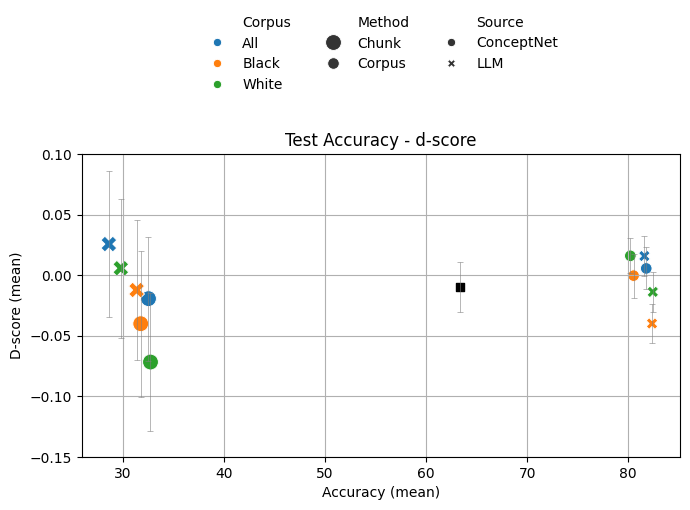

In [19]:
import seaborn as sns

plt.figure(figsize=(7,6))
hl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_mean"][0]
vl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["test_accuracy_mean"][0]
hl_sem = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_sem"][0]

ax = sns.scatterplot(
    data=grouped_filtered_without_baseline,
    hue="Corpus",          
    x="test_accuracy_mean",
    y="d_score_mean",
    style="Source",
    legend ="full",
    size= "Method",
    sizes=(70,130)
)
for _, row in grouped_filtered_without_baseline.iterrows():
    ax.errorbar(
        row["test_accuracy_mean"],
        row["d_score_mean"],
        yerr=row["d_score_sem"],   
        fmt='none',
        capsize=2,
        capthick=0.5,
        elinewidth=0.5,
        ecolor='gray',
        alpha=0.8

    )
# ax.axhline(hl)
# ax.axvline(vl)
ax.grid()
ax.scatter(vl,hl,color="black", marker="s")
ax.errorbar(vl,hl,yerr=hl_sem,fmt='none',capsize=2,capthick=0.5,elinewidth=0.5,ecolor='gray',alpha=0.8)
handles, labelz = ax.get_legend_handles_labels()
print(handles)
print(labelz)
ax.legend(handles=handles, labels = labelz, bbox_to_anchor=(0.5,1.5),loc="upper center",frameon=False,ncol=3)
ax.set_ylim(-0.15,0.10)
ax.set_xlabel("Accuracy (mean)")
ax.set_ylabel("D-score (mean)")
ax.set_title("Test Accuracy - d-score")

plt.tight_layout()
plt.show()

[<matplotlib.lines.Line2D object at 0x000001EAC7583140>, <matplotlib.lines.Line2D object at 0x000001EAC75EB320>, <matplotlib.lines.Line2D object at 0x000001EAC75EB9E0>, <matplotlib.lines.Line2D object at 0x000001EAC75EBC20>, <matplotlib.lines.Line2D object at 0x000001EAC75EBE60>, <matplotlib.lines.Line2D object at 0x000001EAC760C110>, <matplotlib.lines.Line2D object at 0x000001EAC760C320>, <matplotlib.lines.Line2D object at 0x000001EAC760C560>, <matplotlib.lines.Line2D object at 0x000001EAC75EAFC0>, <matplotlib.lines.Line2D object at 0x000001EAC75E9580>]
['Corpus', 'All', 'Black', 'White', 'Method', 'Chunk', 'Corpus', 'Source', 'ConceptNet', 'LLM']


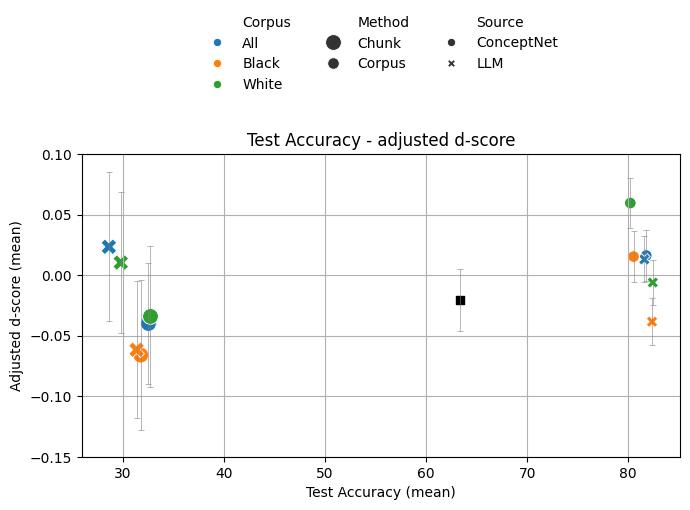

In [20]:
import seaborn as sns

plt.figure(figsize=(7,6))
hl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_with_penalty_only_c_ic_mean"][0]
vl = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["test_accuracy_mean"][0]
hl_sem = grouped_filtered[grouped_filtered['Label'] == 'Baseline']["d_score_with_penalty_only_c_ic_sem"][0]

ax = sns.scatterplot(
    data=grouped_filtered_without_baseline,
    hue="Corpus",          
    x="test_accuracy_mean",
    y="d_score_with_penalty_only_c_ic_mean",
    style="Source",
    legend ="full",
    size= "Method",
    sizes=(70,130)
)
for _, row in grouped_filtered_without_baseline.iterrows():
    ax.errorbar(
        row["test_accuracy_mean"],
        row["d_score_with_penalty_only_c_ic_mean"],
        yerr=row["d_score_with_penalty_only_c_ic_sem"],   
        fmt='none',
        capsize=2,
        capthick=0.5,
        elinewidth=0.5,
        ecolor='gray',
        alpha=0.8

    )

ax.grid()
ax.scatter(vl,hl,color="black", marker="s")
ax.errorbar(vl,hl,yerr=hl_sem,fmt='none',capsize=2,capthick=0.5,elinewidth=0.5,ecolor='gray',alpha=0.8)
handles, labelz = ax.get_legend_handles_labels()
print(handles)
print(labelz)
ax.legend(handles=handles, labels = labelz, bbox_to_anchor=(0.5,1.5),loc="upper center",frameon=False,ncol=3)
ax.set_ylim(-0.15,0.10)
ax.set_xlabel("Test Accuracy (mean)")
ax.set_ylabel("Adjusted d-score (mean)")
ax.set_title("Test Accuracy - adjusted d-score")

plt.tight_layout()
plt.show()

['Source', 'Label', 'relative_path']
['accuracy_mean', 'inc_perc_mean', 'failure_perc_mean', 'noise_perc_mean']
['Source', 'Label', 'relative_path', 'accuracy_mean', 'inc_perc_mean', 'failure_perc_mean', 'noise_perc_mean']


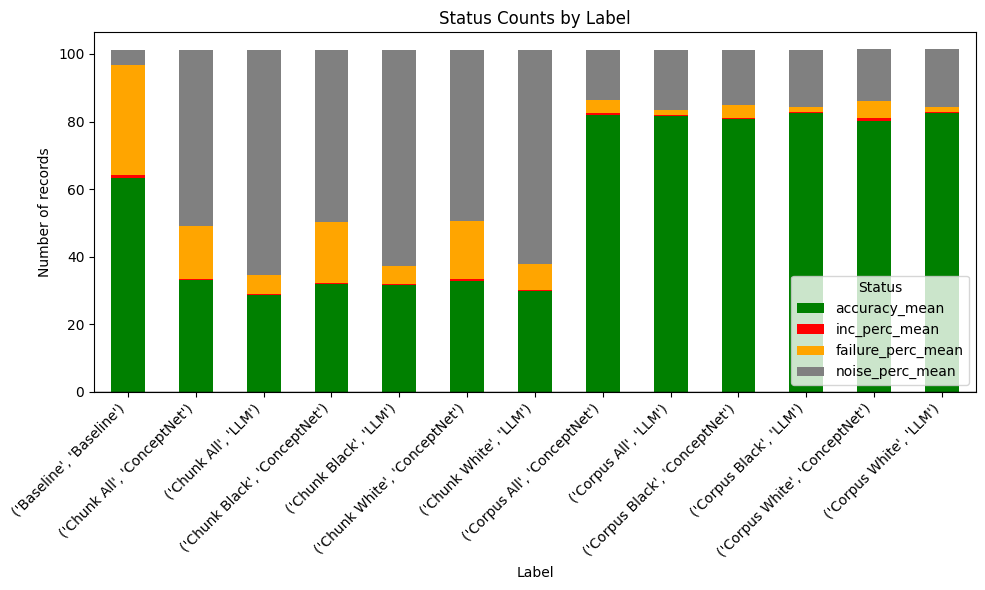

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


status_order_map = {"accuracy_mean":"Correct","inc_perc_mean": "Incorrect", 
                    "failure_perc_mean":"Failed", "noise_perc_mean":"Noise"}
status_cols = list(status_order_map.keys())
status_labels = list(status_order_map.values())

other_cols = ["Source","Label","relative_path"]

other_cols.extend(status_cols)

plotting_df = grouped_filtered[other_cols].copy()
all_paths= ['Baseline', 'CN chunk/no matmul/all', 'LLM chunk/all',
       'CN chunk/no matmul/black', 'LLM chunk/black',
       'CN chunk/no matmul/white', 'LLM chunk/white', 'CN text/all',
       'LLM/all', 'CN text/black', 'LLM/b_llm_2', 'CN text/white',
       'LLM/w_llm_2']

ax = plotting_df.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["green", "red", "orange", "gray"]
)

ax.set_xlabel("Label")
ax.set_ylabel("Number of records")
ax.set_title("Status Counts by Label")
ax.axhline(0, color="black", linewidth=1)


ax.set_xticklabels([display_map[a] for a in all_paths],rotation=45, ha="right")
plt.legend(title="Status")
plt.tight_layout()
plt.show()



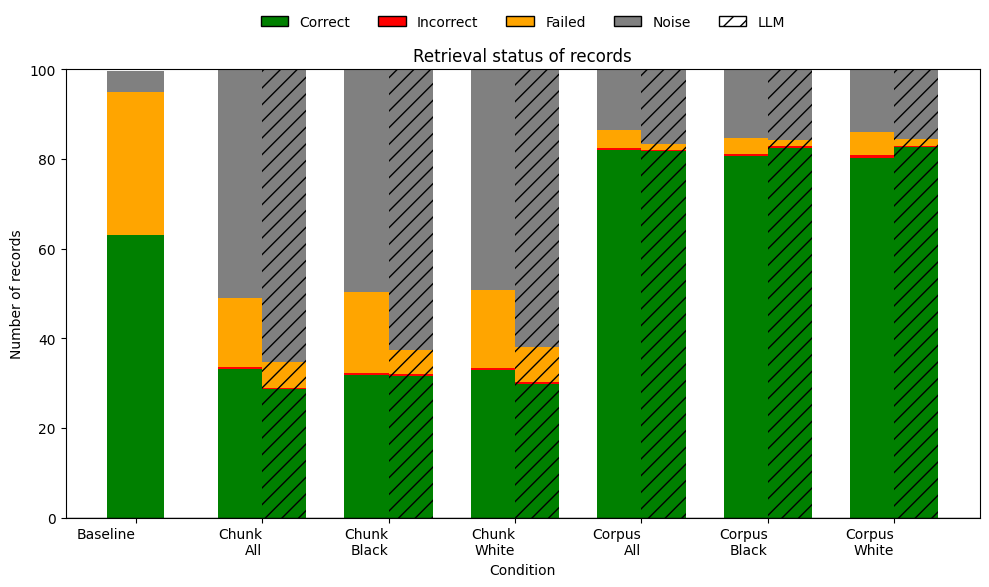

In [30]:

status_colors = {
    "accuracy_mean": "green",
    "inc_perc_mean": "red",
    "failure_perc_mean": "orange",
    "noise_perc_mean": "gray",
}
pbdf = plotting_df[plotting_df["Label"]=="Baseline"]
pcndp = plotting_df[plotting_df["Source"] == "ConceptNet"]
pllmdf = plotting_df[plotting_df["Source"] == "LLM"]
x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

baseline_bottom = 0

for col in status_cols:
    ax.bar(
        x[0],
        pbdf[col].values[0],
        width=0.45,
        bottom=baseline_bottom,
        color=status_colors[col],
        label=status_order_map[col],
        # edgecolor="black"
    )

    baseline_bottom += pbdf[col].astype(int).values[0]


cn_bottom = np.zeros(len(pcndp))

for col in status_cols:
    values = pcndp[col].values

    ax.bar(
        x[1:] - width / 2,
        values,
        width,
        bottom=cn_bottom,
        color=status_colors[col],
        #  edgecolor="black"
    )

    cn_bottom += values


llm_bottom = np.zeros(len(pllmdf))

for col in status_cols:
    values = pllmdf[col].values

    ax.bar(
        x[1:] + width / 2,
        values,
        width,
        bottom=llm_bottom,
        color=status_colors[col],
        #  edgecolor="black",
         hatch="//"
    )

    llm_bottom += values



ax.set_xlabel("Condition")
ax.set_ylabel("Number of records")
ax.set_title("Retrieval status of records")

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(
    [display_map_labels[label] for label in order],
    ha="right"
)
from matplotlib.patches import Patch
status_handles = [
    Patch(facecolor=status_colors[col], edgecolor="black", label=status_order_map[col])
    for col in status_cols
]

source_handles = [
    Patch(facecolor="white", edgecolor="black", hatch="//", label="LLM"),
]

handles = status_handles + source_handles

ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15), 
    ncol=6,
    frameon=False
)
ax.set_ylim(0,100)
plt.tight_layout()
plt.show()

In [ ]:
df1[["Label", "Source"]] = df1["relative_path"].map(display_map).apply(pd.Series)
cleaned_df1 = df1.dropna().copy()
cleaned_df1[["Method","Corpus"]] = cleaned_df1["Label"].str.split(" ",n=1, expand=True)


,relative_path,file_name,d_score,d_score_with_penalty,d_score_with_penalty_without_ret_fail,d_score_with_penalty_only_c_ic,s_count,w_count,correct_recs,accuracy,correct_test_recs,test_accuracy,incorrect_recs,noise_perc,failure_perc,inc_perc,Label,Source,Method,Corpus
0,Baseline,hdm-iat-base_20260427_100404.csv,-0.178324,-0.032832,-0.178324,-0.178324,0,30,41,58.571429,24,60.0,0,0.000000,42.857143,0.0,Baseline,Baseline,Baseline,None
1,Baseline,hdm-iat-base_20260427_100500.csv,0.110716,0.019772,0.110716,0.110716,0,18,53,75.714286,30,75.0,0,0.000000,25.714286,0.0,Baseline,Baseline,Baseline,None
2,Baseline,hdm-iat-base_20260427_100556.csv,0.196719,0.032890,0.057676,0.196719,3,25,43,61.428571,24,60.0,0,4.285714,35.714286,0.0,Baseline,Baseline,Baseline,None
3,Baseline,hdm-iat-base_20260427_100652.csv,0.267291,0.044205,0.267291,0.267291,0,32,39,55.714286,22,55.0,0,0.000000,45.714286,0.0,Baseline,Baseline,Baseline,None
4,Baseline,hdm-iat-base_20260427_100748.csv,0.279489,0.054253,0.279489,0.279489,0,19,52,74.285714,30,75.0,0,0.000000,27.142857,0.0,Baseline,Baseline,Baseline,None


In [33]:
print(cleaned_df1["Label"].unique())
print(cleaned_df1["Method"].unique())
print(cleaned_df1["Corpus"].unique())
print(cleaned_df1["Source"].unique())

['Baseline' 'Chunk All' 'Chunk Black' 'Chunk White' 'Corpus All'
 'Corpus Black' 'Corpus White']
['Baseline' 'Chunk' 'Corpus']
[None 'All' 'Black' 'White']
['Baseline' 'ConceptNet' 'LLM']


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
without_baseline = cleaned_df1[cleaned_df1['Label'] != 'Baseline']
without_baseline_and_chunk = without_baseline[without_baseline['Method']!='Chunk']
model= ols("d_score_with_penalty_only_c_ic ~  C(Source) * C(Corpus)", data=without_baseline_and_chunk).fit()
anova_t = sm.stats.anova_lm(model,typ=2)
anova_t

,sum_sq,df,F,PR(>F)
C(Source),0.251040,1.0,6.296375,0.012364
C(Corpus),0.153187,2.0,1.921059,0.147362
C(Source):C(Corpus),0.109565,2.0,1.374004,0.253896
Residual,23.643237,593.0,NaN,NaN


In [37]:
ss_total = anova_t['sum_sq'].sum()
anova_t['eta_sq'] = anova_t['sum_sq']/ss_total
ss_error = anova_t.loc['Residual','sum_sq']
anova_t['part_eta_sq']=(anova_t['sum_sq']/(anova_t['sum_sq'] + ss_error))
print(anova_t)

                        sum_sq     df         F    PR(>F)    eta_sq  \
C(Source)             0.251040    1.0  6.296375  0.012364  0.010392   
C(Corpus)             0.153187    2.0  1.921059  0.147362  0.006341   
C(Source):C(Corpus)   0.109565    2.0  1.374004  0.253896  0.004536   
Residual             23.643237  593.0       NaN       NaN  0.978731   

                     part_eta_sq  
C(Source)               0.010506  
C(Corpus)               0.006437  
C(Source):C(Corpus)     0.004613  
Residual                0.500000  


In [38]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=without_baseline_and_chunk["d_score_with_penalty_only_c_ic"], groups = without_baseline_and_chunk["Corpus"], alpha = 0.05 )
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   All  Black  -0.0262 0.3938 -0.0734  0.021  False
   All  White   0.0121 0.8184 -0.0351 0.0593  False
 Black  White   0.0383 0.1369 -0.0088 0.0855  False
---------------------------------------------------


In [41]:
from scipy.stats import ttest_ind
for col in columns:
    for src in order[-6:]:
        sdf = without_baseline[without_baseline['Label'] == src]
        group1 = sdf[sdf['Source'] == "ConceptNet"][col]
        group2 = sdf[sdf['Source'] == "LLM"][col]
        
        t_stat, p_val = ttest_ind(group2, group1, equal_var=False, nan_policy='omit')
        
        print(f"{col}: {src}: t = {t_stat:.3f}, p = {p_val:.4f}")
        # Result-> d_score_with_penalty_only_c_ic: Corpus White: t = -2.371, p = 0.0187

d_score: Chunk All: t = 0.569, p = 0.5701
d_score: Chunk Black: t = 0.333, p = 0.7393
d_score: Chunk White: t = 0.960, p = 0.3385
d_score: Corpus All: t = 0.432, p = 0.6666
d_score: Corpus Black: t = -1.613, p = 0.1083
d_score: Corpus White: t = -1.374, p = 0.1710
d_score_with_penalty: Chunk All: t = 0.433, p = 0.6655
d_score_with_penalty: Chunk Black: t = -0.134, p = 0.8933
d_score_with_penalty: Chunk White: t = 0.587, p = 0.5580
d_score_with_penalty: Corpus All: t = -0.385, p = 0.7005
d_score_with_penalty: Corpus Black: t = -1.361, p = 0.1751
d_score_with_penalty: Corpus White: t = -2.174, p = 0.0311
d_score_with_penalty_without_ret_fail: Chunk All: t = 0.583, p = 0.5609
d_score_with_penalty_without_ret_fail: Chunk Black: t = -0.158, p = 0.8744
d_score_with_penalty_without_ret_fail: Chunk White: t = 0.616, p = 0.5387
d_score_with_penalty_without_ret_fail: Corpus All: t = -0.538, p = 0.5915
d_score_with_penalty_without_ret_fail: Corpus Black: t = -1.483, p = 0.1396
d_score_with_penalt